# Step 3: Neural Network Classifier (MLP)

This notebook implements a Multi-Layer Perceptron (Neural Network) classifier for MNIST digit classification to compare with the KNN approach.

In [1]:
import numpy as np
import struct
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
import seaborn as sns
import time

%matplotlib inline

## 1. Load Dataset

In [2]:
def read_idx_images(filename):
    with open(filename, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.fromfile(f, dtype=np.uint8).reshape(num_images, rows, cols)
    return images

def read_idx_labels(filename):
    with open(filename, 'rb') as f:
        magic, num_labels = struct.unpack('>II', f.read(8))
        labels = np.fromfile(f, dtype=np.uint8)
    return labels

In [3]:
train_images = read_idx_images('../data/train-images.idx3-ubyte')
train_labels = read_idx_labels('../data/train-labels.idx1-ubyte')
test_images = read_idx_images('../data/t10k-images.idx3-ubyte')
test_labels = read_idx_labels('../data/t10k-labels.idx1-ubyte')

print(f"Training set: {train_images.shape}")
print(f"Test set: {test_images.shape}")

Training set: (60000, 28, 28)
Test set: (10000, 28, 28)


## 2. Data Preprocessing

### 2.1 Flatten Images & Normalize
Neural networks benefit significantly from normalized inputs (0-1 range).

In [4]:
X_train = train_images.reshape(train_images.shape[0], -1).astype('float32') / 255.0
X_test = test_images.reshape(test_images.shape[0], -1).astype('float32') / 255.0
y_train = train_labels
y_test = test_labels

print(f"Flattened training data: {X_train.shape}")
print(f"Flattened test data: {X_test.shape}")
print(f"Normalized range: [{X_train.min():.2f}, {X_train.max():.2f}]")

Flattened training data: (60000, 784)
Flattened test data: (10000, 784)
Normalized range: [0.00, 1.00]


## 3. Hyperparameter Tuning

We will test different hidden layer sizes to find a good balance between performance and complexity.

In [5]:
subset_size = 10000
X_train_subset = X_train[:subset_size]
y_train_subset = y_train[:subset_size]

layer_configs = [
    (64,),          # Single small layer
    (128,),         # Single medium layer
    (128, 64),      # Two layers
    (256, 128, 64)  # Three layers (Deep)
]

cv_scores = []

print("Testing different architectures...")
for config in layer_configs:
    mlp = MLPClassifier(hidden_layer_sizes=config, max_iter=50, random_state=42)
    scores = cross_val_score(mlp, X_train_subset, y_train_subset, cv=3, scoring='accuracy')
    cv_scores.append(scores.mean())
    print(f"Layers {config}: {scores.mean():.4f} (+/- {scores.std():.4f})")

best_config = layer_configs[np.argmax(cv_scores)]
print(f"\nBest Architecture: {best_config} with accuracy: {max(cv_scores):.4f}")

Testing different architectures...


/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Layers (64,): 0.9359 (+/- 0.0085)


/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Layers (128,): 0.9425 (+/- 0.0058)


/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Layers (128, 64): 0.9454 (+/- 0.0065)
Layers (256, 128, 64): 0.9477 (+/- 0.0061)

Best Architecture: (256, 128, 64) with accuracy: 0.9477


## 4. Train Final Model

Train the MLP with the best architecture on the full training set.

In [6]:
print(f"Training MLP with layers={best_config} on full training set...")
start_time = time.time()

mlp_final = MLPClassifier(hidden_layer_sizes=best_config, max_iter=200, random_state=42, verbose=True)
mlp_final.fit(X_train, y_train)

train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds")

Training MLP with layers=(256, 128, 64) on full training set...
Iteration 1, loss = 0.31503253
Iteration 2, loss = 0.11303252
Iteration 3, loss = 0.07512322
Iteration 4, loss = 0.05514518
Iteration 5, loss = 0.04141056
Iteration 6, loss = 0.03105251
Iteration 7, loss = 0.02562132
Iteration 8, loss = 0.02009845
Iteration 9, loss = 0.01624490
Iteration 10, loss = 0.01802564
Iteration 11, loss = 0.01465917
Iteration 12, loss = 0.00847481
Iteration 13, loss = 0.01104023
Iteration 14, loss = 0.01545779
Iteration 15, loss = 0.01070700
Iteration 16, loss = 0.01035355
Iteration 17, loss = 0.00723739
Iteration 18, loss = 0.00670953
Iteration 19, loss = 0.00862034
Iteration 20, loss = 0.01069232
Iteration 21, loss = 0.00647190
Iteration 22, loss = 0.01127125
Iteration 23, loss = 0.00621043
Iteration 24, loss = 0.00919651
Iteration 25, loss = 0.00757617
Iteration 26, loss = 0.00621383
Iteration 27, loss = 0.00452693
Iteration 28, loss = 0.00230433
Iteration 29, loss = 0.01004320
Iteration 30, los

### Visualize Loss Curve

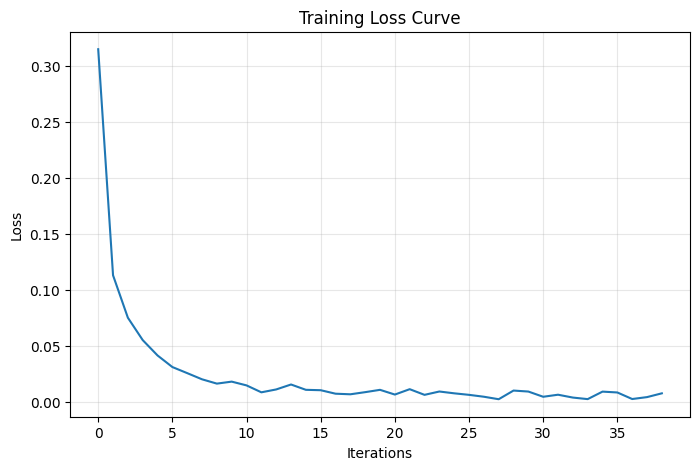

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(mlp_final.loss_curve_)
plt.title('Training Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Model Evaluation

### 5.1 Make Predictions

In [8]:
print("Making predictions on test set...")
start_time = time.time()

y_pred = mlp_final.predict(X_test)

pred_time = time.time() - start_time
print(f"Predictions completed in {pred_time:.2f} seconds")
print(f"Average prediction time: {(pred_time / len(X_test)) * 1000:.2f} ms per sample")

Making predictions on test set...
Predictions completed in 0.03 seconds
Average prediction time: 0.00 ms per sample


### 5.2 Overall Accuracy

In [9]:
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")
print(f"Misclassified samples: {np.sum(y_pred != y_test)} out of {len(y_test)}")

Test Accuracy: 0.9821 (98.21%)
Error Rate: 0.0179 (1.79%)
Misclassified samples: 179 out of 10000


### 5.3 Confusion Matrix

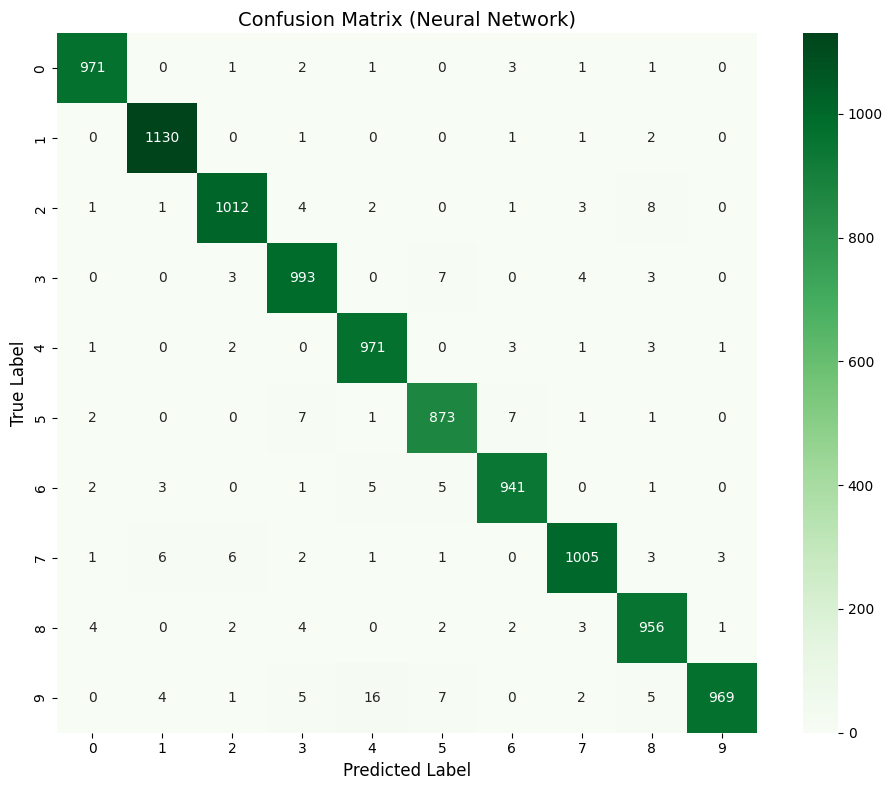

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', square=True)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix (Neural Network)', fontsize=14)
plt.tight_layout()
plt.show()

### 5.4 Per-Class Performance

In [11]:
print("Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, digits=4))

Classification Report:
              precision    recall  f1-score   support

           0     0.9888    0.9908    0.9898       980
           1     0.9878    0.9956    0.9917      1135
           2     0.9854    0.9806    0.9830      1032
           3     0.9745    0.9832    0.9788      1010
           4     0.9739    0.9888    0.9813       982
           5     0.9754    0.9787    0.9771       892
           6     0.9823    0.9823    0.9823       958
           7     0.9843    0.9776    0.9810      1028
           8     0.9725    0.9815    0.9770       974
           9     0.9949    0.9604    0.9773      1009

    accuracy                         0.9821     10000
   macro avg     0.9820    0.9819    0.9819     10000
weighted avg     0.9822    0.9821    0.9821     10000



## 6. Error Analysis

### 6.1 Visualize Misclassified Samples

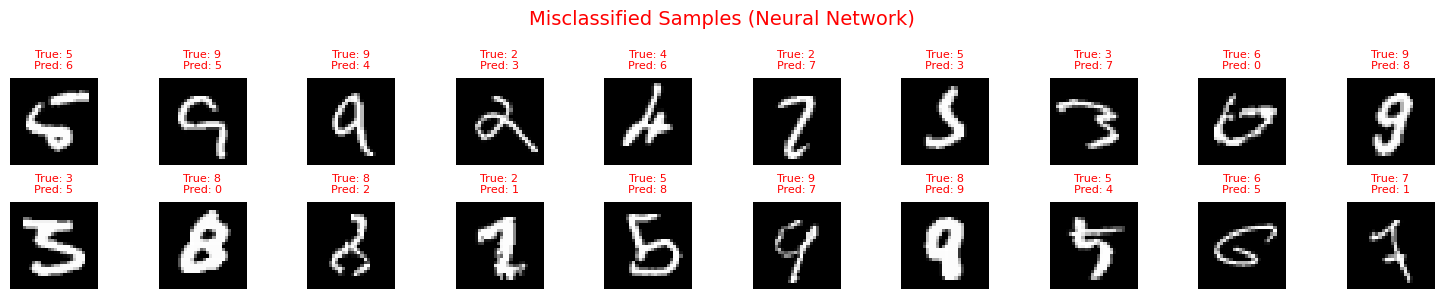

In [12]:
misclassified_idx = np.where(y_pred != y_test)[0]
sample_errors = misclassified_idx[:20]

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle('Misclassified Samples (Neural Network)', fontsize=14, color='red')

for i, idx in enumerate(sample_errors):
    ax = axes[i // 10, i % 10]
    ax.imshow(test_images[idx], cmap='gray')
    ax.set_title(f'True: {y_test[idx]}\nPred: {y_pred[idx]}', fontsize=8, color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 7. Summary & Comparison

### Comparison with KNN

In [13]:
print("=" * 60)
print("NEURAL NETWORK CLASSIFIER - PERFORMANCE SUMMARY")
print("=" * 60)
print(f"Architecture: {best_config}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Training time: {train_time:.2f}s")
print(f"Prediction time: {pred_time:.2f}s ({(pred_time/len(X_test))*1000:.2f}ms per sample)")
print("=" * 60)

print("\nComparison Notes:")
print("1. Inference Speed: Neural Networks are generally much faster at prediction time than KNN.")
print("   - KNN needs to compare with ALL training samples.")
print("   - NN just does a forward pass through the layers.")
print("2. Training Speed: KNN has zero training time (lazy learning), while NN requires iterative training.")
print("3. Accuracy: NNs often outperform KNN on complex image data, especially with more data and layers.")

NEURAL NETWORK CLASSIFIER - PERFORMANCE SUMMARY
Architecture: (256, 128, 64)
Test Accuracy: 0.9821 (98.21%)
Training time: 17.42s
Prediction time: 0.03s (0.00ms per sample)

Comparison Notes:
1. Inference Speed: Neural Networks are generally much faster at prediction time than KNN.
   - KNN needs to compare with ALL training samples.
   - NN just does a forward pass through the layers.
2. Training Speed: KNN has zero training time (lazy learning), while NN requires iterative training.
3. Accuracy: NNs often outperform KNN on complex image data, especially with more data and layers.
